ANOVA analysis - day-blocked CV

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
from scipy.stats import shapiro, levene, bartlett, anderson, normaltest

import pingouin as pg
from itertools import combinations
import matplotlib.pyplot as plt

In [2]:
# normality and homogeneity of variance tests for ANOVA assumptions
def check_anova_assumptions(df, group_col, metric_col, group_order=None):
    if group_order is None:
        group_order = df[group_col].unique()

    print(f"\n=== Normality test (D’Agostino and Pearson) for {metric_col} ===")
    for group in group_order:
        data = df[df[group_col] == group][metric_col]
        stat, p = normaltest(data)
        result = "OK normal" if p > 0.05 else "not normal"
        print(f"{group.ljust(25)}:\tp = {p:.4f}\t→\t{result}")

    print(f"\n=== Normality test (Shapiro-Wilk) for {metric_col} ===")
    for group in group_order:
        data = df[df[group_col] == group][metric_col]
        stat, p = shapiro(data)
        result = "OK normal" if p > 0.05 else "not normal"
        print(f"{group.ljust(25)}:\tp = {p:.4f}\t→\t{result}")

    print(f"\n=== Normality test (Anderson-Darling) for {metric_col} ===")
    for group in group_order:
        data = df[df[group_col] == group][metric_col]
        result = anderson(data)
        stat = result.statistic
        crit_5 = result.critical_values[2]
        interpretation = "OK normal" if stat < crit_5 else "not normal"
        print(f"{group.ljust(25)}:\tA² = {stat:.4f},\t5% critical = {crit_5:.4f}\t→\t{interpretation}")

    print(f"\n=== Homogeneity of variance tests for {metric_col} ===")
    groups = [df[df[group_col] == group][metric_col] for group in group_order]

    stat_levene, p_levene = levene(*groups)
    result_levene = "OK equal variances" if p_levene > 0.05 else "unequal variances"
    print(f"Levene’s test  : p = {p_levene:.4f}\t→\t{result_levene}")

    stat_bartlett, p_bartlett = bartlett(*groups)
    result_bartlett = "OK equal variances" if p_bartlett > 0.05 else "unequal variances"
    print(f"Bartlett’s test: p = {p_bartlett:.4f}\t→\t{result_bartlett}")

    # Brown–Forsythe test (Levene with center='median')
    stat_bf, p_bf = levene(*groups, center='median')
    result_bf = "OK equal variances" if p_bf > 0.05 else "unequal variances"
    print(f"Brown–Forsythe : p = {p_bf:.4f}\t→\t{result_bf}")

In [3]:
def interpret_eta2(x: float) -> str:
    if x < 0.01:
        return "negligible"
    elif x < 0.06:
        return "small"
    elif x < 0.14:
        return "medium"
    else:
        return "large"

def interpret_d_like(x: float) -> str:
    ax = abs(x)
    if ax < 0.2:
        return "negligible"
    elif ax < 0.5:
        return "small"
    elif ax < 0.8:
        return "medium"
    else:
        return "large"

In [4]:
# ANOVA with eta squared, Games-Howell posthoc, and pairwise Hedges g effect sizes
def run_anova_full(df, group_col, metric_col, show_ci=True):
    # ===== Welch ANOVA =====
    print(f"\n=== Welch ANOVA for {metric_col} ===")
    welch = pg.welch_anova(dv=metric_col, between=group_col, data=df)
    print(welch.to_string(index=False))

    # Overall effect size (np2) interpretation
    if "np2" in welch.columns:
        np2 = float(welch.loc[0, "np2"])
        print(f"\nEffect size (partial η², np2) = {np2:.4f} → {interpret_eta2(np2)} effect")
    else:
        np2 = None
        print("\nEffect size: np2 not provided by Welch ANOVA output.")

    # ===== Games-Howell post-hoc =====
    print(f"\n=== Games-Howell post-hoc test for {metric_col} ===")
    gh = pg.pairwise_gameshowell(dv=metric_col, between=group_col, data=df).copy()
    print(gh.to_string(index=False))

    # ===== Pairwise effect sizes =====
    print(f"\n=== Pairwise effect sizes for {metric_col} (Hedges' g) ===")
    group_labels = list(pd.unique(df[group_col]))
    label_width = max(len(str(g)) for g in group_labels) + 2

    for g1, g2 in combinations(group_labels, 2):
        x = df.loc[df[group_col] == g1, metric_col].to_numpy()
        y = df.loc[df[group_col] == g2, metric_col].to_numpy()

        g = float(pg.compute_effsize(x, y, eftype="hedges"))
        effect = interpret_d_like(g)

        line = (
            f"{str(g1).ljust(label_width)} vs {str(g2).ljust(label_width)}:"
            f" g = {g:.4f} → {effect} effect"
        )

        if show_ci:
            ci = pg.compute_bootci(
                x, y,
                func=lambda a, b: pg.compute_effsize(a, b, eftype="hedges"),
                confidence=0.95,
                method="percentile",
            )
            line += f"   95% CI [{ci[0]:.4f}, {ci[1]:.4f}]"

        print(line)

## Time independent - CO2

In [5]:
model = "time independent CO2"
A_low = pd.read_csv(
    "../_timeindep_results_raw/case_LabEEE_A_low_state_timeindep_co2.csv")
A_mid = pd.read_csv(
    "../_timeindep_results_raw/case_LabEEE_A_mid_state_timeindep_co2.csv")
A_top = pd.read_csv(
    "../_timeindep_results_raw/case_LabEEE_A_top_state_timeindep_co2.csv")
B_low = pd.read_csv(
    "../_timeindep_results_raw/case_LabEEE_B_low_state_timeindep_co2.csv")
B_mid = pd.read_csv(
    "../_timeindep_results_raw/case_LabEEE_B_mid_state_timeindep_co2.csv")
B_top = pd.read_csv(
    "../_timeindep_results_raw/case_LabEEE_B_top_state_timeindep_co2.csv")
C_mid = pd.read_csv(
    "../_timeindep_results_raw/case_LabEEE_C_mid_state_timeindep_co2.csv")
C_top = pd.read_csv(
    "../_timeindep_results_raw/case_LabEEE_C_top_state_timeindep_co2.csv")


In [6]:
A_low.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,50.0,24.500000,14.577380,0.000000,12.250000,24.500000,36.750000,49.000000
repeat,50.0,4.500000,2.901442,0.000000,2.000000,4.500000,7.000000,9.000000
fold,50.0,2.000000,1.428571,0.000000,1.000000,2.000000,3.000000,4.000000
split_id,50.0,24.500000,14.577380,0.000000,12.250000,24.500000,36.750000,49.000000
accuracy,50.0,0.865197,0.039735,0.766871,0.844396,0.867780,0.894943,0.953125
f1_weighted,50.0,0.862272,0.041396,0.755143,0.840807,0.865859,0.892846,0.952099
balanced_acc,50.0,0.827098,0.031841,0.754373,0.806968,0.824733,0.845089,0.911719
auc,50.0,0.903180,0.031082,0.818302,0.887142,0.906410,0.923406,0.959662
model_weights.random_forest,50.0,1.312310,1.255545,-1.934520,0.590099,1.257406,2.181348,3.931230
model_weights.bagging_svc,50.0,0.459804,0.549530,-0.522958,0.085112,0.409370,0.770186,1.974195


In [7]:
A_mid.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,50.0,24.500000,14.577380,0.000000,12.250000,24.500000,36.750000,49.000000
repeat,50.0,4.500000,2.901442,0.000000,2.000000,4.500000,7.000000,9.000000
fold,50.0,2.000000,1.428571,0.000000,1.000000,2.000000,3.000000,4.000000
split_id,50.0,24.500000,14.577380,0.000000,12.250000,24.500000,36.750000,49.000000
accuracy,50.0,0.868560,0.047746,0.765337,0.831800,0.874566,0.900708,0.960669
f1_weighted,50.0,0.864417,0.050935,0.753295,0.827662,0.871984,0.899868,0.958721
balanced_acc,50.0,0.829750,0.047276,0.696237,0.792514,0.836518,0.864555,0.907350
auc,50.0,0.897588,0.043416,0.758798,0.878577,0.907493,0.927013,0.966495
model_weights.random_forest,50.0,0.194614,1.384821,-2.604350,-0.960744,0.061005,0.945360,3.492730
model_weights.bagging_svc,50.0,0.523155,0.845908,-1.497335,-0.115115,0.616350,1.123720,2.043925


In [8]:
A_top.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,50.0,24.500000,14.577380,0.000000,12.250000,24.500000,36.750000,49.000000
repeat,50.0,4.500000,2.901442,0.000000,2.000000,4.500000,7.000000,9.000000
fold,50.0,2.000000,1.428571,0.000000,1.000000,2.000000,3.000000,4.000000
split_id,50.0,24.500000,14.577380,0.000000,12.250000,24.500000,36.750000,49.000000
accuracy,50.0,0.870178,0.047242,0.761503,0.836124,0.874565,0.903255,0.959685
f1_weighted,50.0,0.867944,0.049192,0.752082,0.834923,0.873242,0.905611,0.956720
balanced_acc,50.0,0.840517,0.042493,0.751991,0.811471,0.837858,0.872447,0.915556
auc,50.0,0.907215,0.037243,0.811113,0.881801,0.912500,0.937620,0.964915
model_weights.random_forest,50.0,0.788497,0.859399,-1.262010,0.401959,0.722851,1.265563,2.777417
model_weights.bagging_svc,50.0,-0.036523,1.305022,-1.648247,-1.007790,-0.478442,0.619683,3.122971


In [9]:
B_low.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,50.0,24.500000,14.577380,0.000000,12.250000,24.500000,36.750000,49.000000
repeat,50.0,4.500000,2.901442,0.000000,2.000000,4.500000,7.000000,9.000000
fold,50.0,2.000000,1.428571,0.000000,1.000000,2.000000,3.000000,4.000000
split_id,50.0,24.500000,14.577380,0.000000,12.250000,24.500000,36.750000,49.000000
accuracy,50.0,0.837450,0.047681,0.733961,0.804485,0.837894,0.874132,0.929688
f1_weighted,50.0,0.832902,0.050809,0.722108,0.798008,0.833337,0.874014,0.930046
balanced_acc,50.0,0.793528,0.038324,0.709067,0.764716,0.793187,0.822176,0.874685
auc,50.0,0.870615,0.041549,0.786234,0.845953,0.872981,0.901642,0.935921
model_weights.random_forest,50.0,0.108241,1.244525,-2.715277,-0.715802,0.006648,0.850160,2.473525
model_weights.bagging_svc,50.0,0.383319,0.541096,-0.631790,0.043053,0.361618,0.722820,1.820168


In [10]:
B_mid.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,50.0,24.500000,14.577380,0.000000,12.250000,24.500000,36.750000,49.000000
repeat,50.0,4.500000,2.901442,0.000000,2.000000,4.500000,7.000000,9.000000
fold,50.0,2.000000,1.428571,0.000000,1.000000,2.000000,3.000000,4.000000
split_id,50.0,24.500000,14.577380,0.000000,12.250000,24.500000,36.750000,49.000000
accuracy,50.0,0.850832,0.052952,0.740798,0.811325,0.859809,0.893354,0.954769
f1_weighted,50.0,0.848026,0.054596,0.727718,0.809212,0.857735,0.887480,0.953330
balanced_acc,50.0,0.816790,0.042458,0.729986,0.786542,0.811891,0.840349,0.902125
auc,50.0,0.883345,0.043405,0.798759,0.854442,0.882184,0.913800,0.959165
model_weights.random_forest,50.0,0.503425,1.274975,-1.840504,-0.489312,0.232225,1.631570,3.016546
model_weights.bagging_svc,50.0,0.825668,0.730460,-0.524868,0.245400,1.051164,1.473395,2.218898


In [11]:
B_top.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,50.0,24.500000,14.577380,0.000000,12.250000,24.500000,36.750000,49.000000
repeat,50.0,4.500000,2.901442,0.000000,2.000000,4.500000,7.000000,9.000000
fold,50.0,2.000000,1.428571,0.000000,1.000000,2.000000,3.000000,4.000000
split_id,50.0,24.500000,14.577380,0.000000,12.250000,24.500000,36.750000,49.000000
accuracy,50.0,0.880964,0.043141,0.776074,0.849204,0.885224,0.914646,0.975418
f1_weighted,50.0,0.879036,0.044411,0.768704,0.843811,0.886505,0.913670,0.973093
balanced_acc,50.0,0.852199,0.037926,0.767443,0.823875,0.855111,0.876918,0.927323
auc,50.0,0.907549,0.040262,0.817462,0.877909,0.914453,0.933841,0.970281
model_weights.random_forest,50.0,-0.188581,0.943946,-2.388299,-0.782657,-0.366281,0.623794,1.434737
model_weights.bagging_svc,50.0,0.066702,0.926202,-1.564664,-0.575798,-0.102166,0.709244,2.044607


In [12]:
C_mid.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,50.0,24.500000,14.577380,0.000000,12.250000,24.500000,36.750000,49.000000
repeat,50.0,4.500000,2.901442,0.000000,2.000000,4.500000,7.000000,9.000000
fold,50.0,2.000000,1.428571,0.000000,1.000000,2.000000,3.000000,4.000000
split_id,50.0,24.500000,14.577380,0.000000,12.250000,24.500000,36.750000,49.000000
accuracy,50.0,0.872414,0.044533,0.776074,0.835590,0.879250,0.901691,0.947886
f1_weighted,50.0,0.869732,0.046740,0.766703,0.832532,0.878611,0.897868,0.949161
balanced_acc,50.0,0.840021,0.039521,0.744416,0.810513,0.842532,0.863174,0.926103
auc,50.0,0.899914,0.044211,0.781471,0.880986,0.905354,0.929716,0.973652
model_weights.random_forest,50.0,0.686469,1.180186,-1.914262,-0.078721,0.890183,1.437771,3.070946
model_weights.bagging_svc,50.0,0.201322,0.519993,-1.010871,-0.094730,0.250129,0.535063,1.186593


In [13]:
C_top.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,50.0,24.500000,14.577380,0.000000,12.250000,24.500000,36.750000,49.000000
repeat,50.0,4.500000,2.901442,0.000000,2.000000,4.500000,7.000000,9.000000
fold,50.0,2.000000,1.428571,0.000000,1.000000,2.000000,3.000000,4.000000
split_id,50.0,24.500000,14.577380,0.000000,12.250000,24.500000,36.750000,49.000000
accuracy,50.0,0.863320,0.049651,0.773006,0.824018,0.855035,0.908763,0.979351
f1_weighted,50.0,0.859658,0.052121,0.761379,0.824439,0.853002,0.906010,0.978036
balanced_acc,50.0,0.827797,0.041060,0.717433,0.795604,0.832563,0.861950,0.909026
auc,50.0,0.896279,0.040617,0.720396,0.871755,0.899258,0.922322,0.956476
model_weights.random_forest,50.0,0.475773,1.194096,-1.725051,-0.499025,0.266403,1.296794,3.015283
model_weights.bagging_svc,50.0,-0.185409,0.783953,-1.980994,-0.738818,-0.327503,0.286797,1.947128


In [14]:
A_low['case'] = 'A_low'
A_mid['case'] = 'A_mid'
A_top['case'] = 'A_top'
B_low['case'] = 'B_low'
B_mid['case'] = 'B_mid'
B_top['case'] = 'B_top'
C_mid['case'] = 'C_mid'
C_top['case'] = 'C_top'

metrics = ["case", "accuracy", "f1_weighted", "balanced_acc", "auc"]

df_metrics = pd.concat(
    [
        A_low[metrics],
        A_mid[metrics],
        A_top[metrics],
        B_low[metrics],
        B_mid[metrics],
        B_top[metrics],
        C_mid[metrics],
        C_top[metrics],
    ],
    ignore_index=True
)

df_metrics.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   case          400 non-null    object 
 1   accuracy      400 non-null    float64
 2   f1_weighted   400 non-null    float64
 3   balanced_acc  400 non-null    float64
 4   auc           400 non-null    float64
dtypes: float64(4), object(1)
memory usage: 15.8+ KB


In [15]:
case_order = ['A_low', 'A_mid', 'A_top', 'B_low', 'B_mid', 'B_top', 'C_mid', 'C_top']
df_metrics['x'] = df_metrics['case'].map({name: i for i, name in enumerate(case_order)})
df_metrics['x_jitter'] = df_metrics['x'] + np.random.uniform(-0.1, 0.1, size=len(df_metrics))

df_metrics.head().T

,0,1,2,3,4
case,A_low,A_low,A_low,A_low,A_low
accuracy,0.859028,0.868199,0.855932,0.902778,0.858268
f1_weighted,0.853616,0.866993,0.8457,0.902323,0.853935
balanced_acc,0.818976,0.841673,0.780382,0.886579,0.814986
auc,0.923793,0.883179,0.899474,0.949881,0.911611
x,0,0,0,0,0
x_jitter,0.086661,0.018903,0.054981,0.092807,-0.070653


### plot

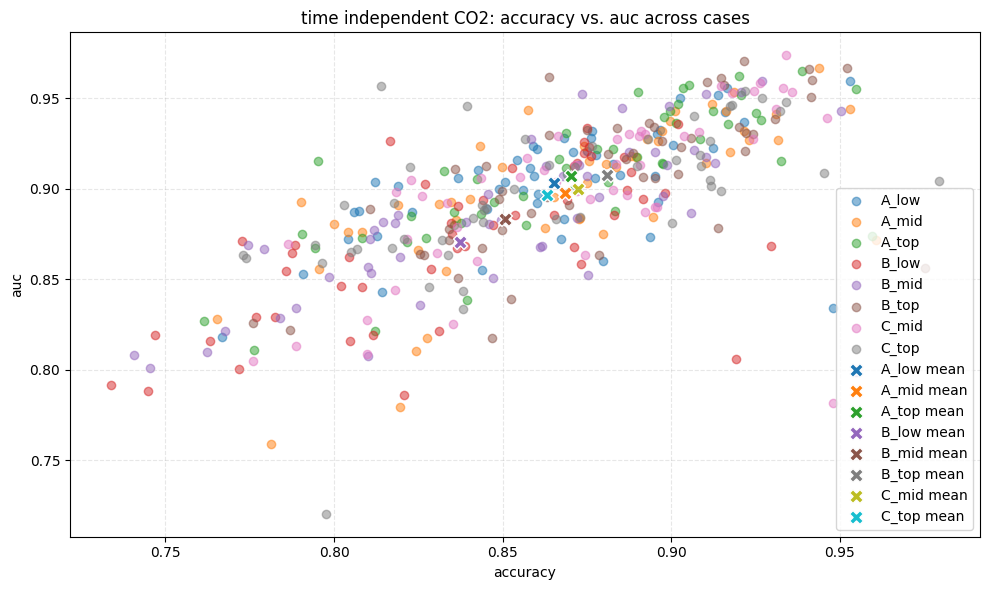

In [16]:
# plot metrics
metrics_plot = ["accuracy", "auc"]

colors = plt.cm.tab10(np.linspace(0, 1, len(case_order)))
case_color_map = {case: color for case, color in zip(case_order, colors)}
plt.figure(figsize=(10, 6))

for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset[metrics_plot[0]], subset[metrics_plot[1]], alpha=0.5, label=case)

# average
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    mean_x = subset[metrics_plot[0]].mean()
    mean_y = subset[metrics_plot[1]].mean()
    plt.scatter(mean_x, mean_y, marker='X', color=case_color_map[case], edgecolor='white', s=100, label=f'{case} mean')

plt.xlabel(f"{metrics_plot[0]}")
plt.ylabel(f"{metrics_plot[1]}")
plt.title(f"{model}: {metrics_plot[0]} vs. {metrics_plot[1]} across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

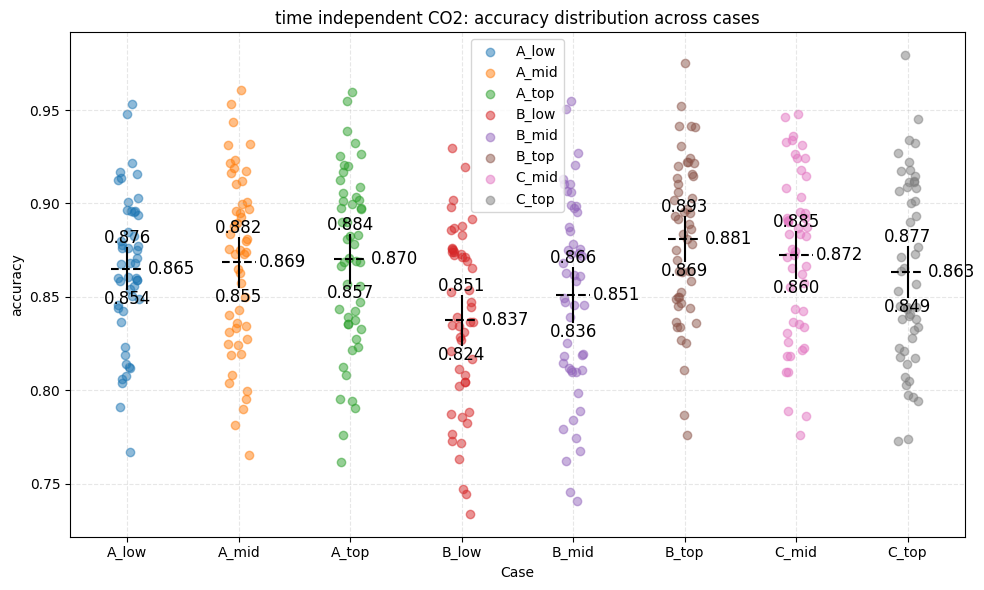

In [17]:
# plot accuracy
metric = "accuracy"

plt.figure(figsize=(10, 6))
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset['x_jitter'], subset[metric], alpha=0.5, label=case)

for i, case in enumerate(case_order):
    vals = df_metrics[df_metrics['case'] == case][metric].values
    n = len(vals)
    mean_val = np.mean(vals)
    sem = stats.sem(vals)                  # standard error
    ci_low, ci_high = stats.t.interval(
        0.95, n - 1, loc=mean_val, scale=sem
    )
    plt.hlines(mean_val, i - 0.15, i + 0.15, colors='black', linestyles='dashed')
    plt.text(i + 0.18, mean_val, f"{mean_val:.3f}", va="center", ha="left", fontsize=12, color="black")
    plt.vlines(i, ci_low, ci_high, colors='black', linewidth=1.5)
    plt.text(i, ci_low, f"{ci_low:.3f}", va="top", ha="center", fontsize=12, color="black")
    plt.text(i, ci_high, f"{ci_high:.3f}", va="bottom", ha="center", fontsize=12, color="black")

plt.xticks(range(len(case_order)), case_order)
plt.xlabel("Case")
plt.ylabel(metric)
plt.title(f"{model}: {metric} distribution across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

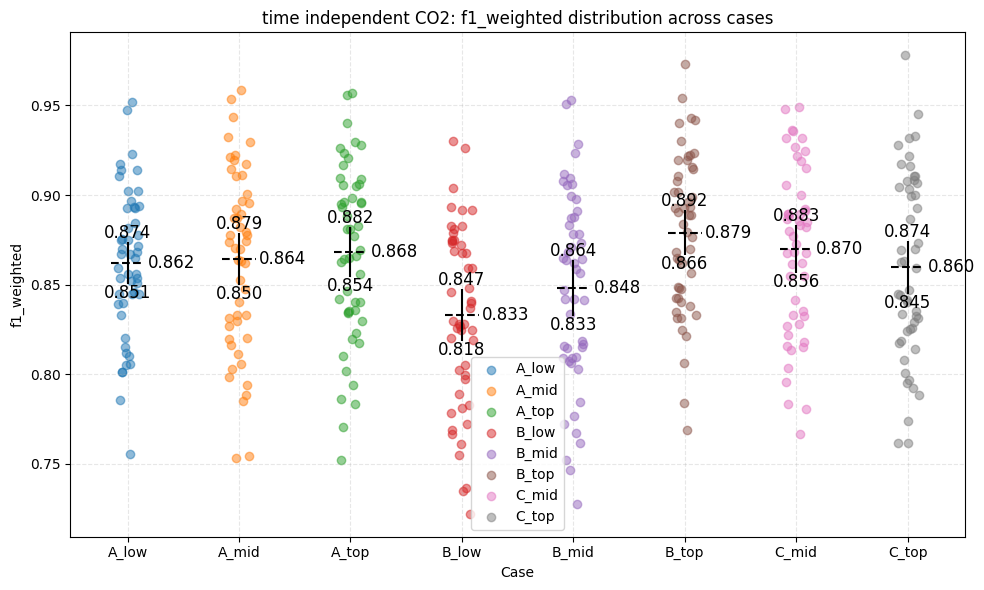

In [18]:
# plot f1 score
metric = "f1_weighted"

plt.figure(figsize=(10, 6))
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset['x_jitter'], subset[metric], alpha=0.5, label=case)

for i, case in enumerate(case_order):
    vals = df_metrics[df_metrics['case'] == case][metric].values
    n = len(vals)
    mean_val = np.mean(vals)
    sem = stats.sem(vals)                  # standard error
    ci_low, ci_high = stats.t.interval(
        0.95, n - 1, loc=mean_val, scale=sem
    )
    plt.hlines(mean_val, i - 0.15, i + 0.15, colors='black', linestyles='dashed')
    plt.text(i + 0.18, mean_val, f"{mean_val:.3f}", va="center", ha="left", fontsize=12, color="black")
    plt.vlines(i, ci_low, ci_high, colors='black', linewidth=1.5)
    plt.text(i, ci_low, f"{ci_low:.3f}", va="top", ha="center", fontsize=12, color="black")
    plt.text(i, ci_high, f"{ci_high:.3f}", va="bottom", ha="center", fontsize=12, color="black")

plt.xticks(range(len(case_order)), case_order)
plt.xlabel("Case")
plt.ylabel(metric)
plt.title(f"{model}: {metric} distribution across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

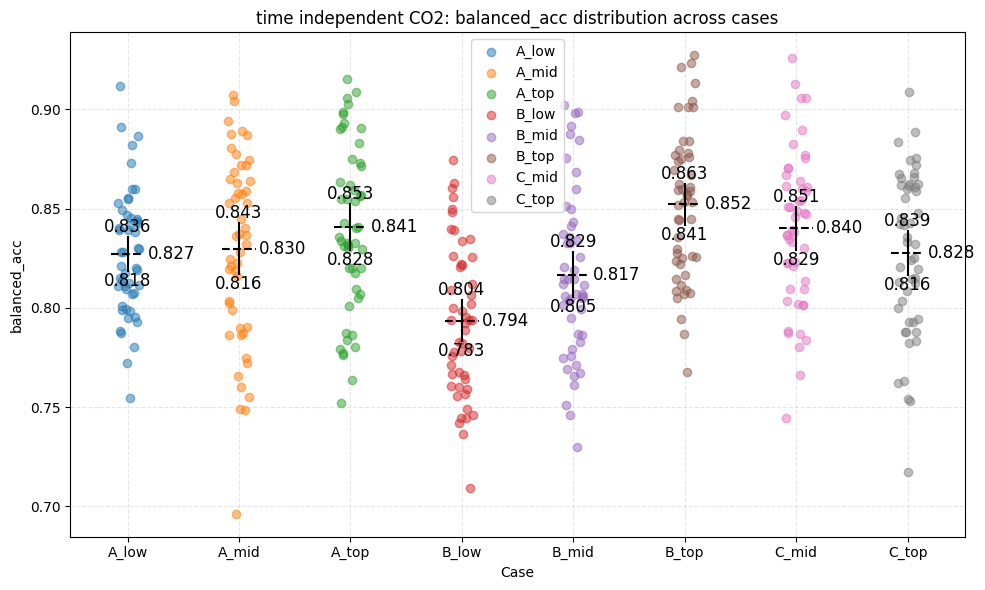

In [19]:
# plot balanced accuracy
metric = "balanced_acc"

plt.figure(figsize=(10, 6))
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset['x_jitter'], subset[metric], alpha=0.5, label=case)

for i, case in enumerate(case_order):
    vals = df_metrics[df_metrics['case'] == case][metric].values
    n = len(vals)
    mean_val = np.mean(vals)
    sem = stats.sem(vals)                  # standard error
    ci_low, ci_high = stats.t.interval(
        0.95, n - 1, loc=mean_val, scale=sem
    )
    plt.hlines(mean_val, i - 0.15, i + 0.15, colors='black', linestyles='dashed')
    plt.text(i + 0.18, mean_val, f"{mean_val:.3f}", va="center", ha="left", fontsize=12, color="black")
    plt.vlines(i, ci_low, ci_high, colors='black', linewidth=1.5)
    plt.text(i, ci_low, f"{ci_low:.3f}", va="top", ha="center", fontsize=12, color="black")
    plt.text(i, ci_high, f"{ci_high:.3f}", va="bottom", ha="center", fontsize=12, color="black")

plt.xticks(range(len(case_order)), case_order)
plt.xlabel("Case")
plt.ylabel(metric)
plt.title(f"{model}: {metric} distribution across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

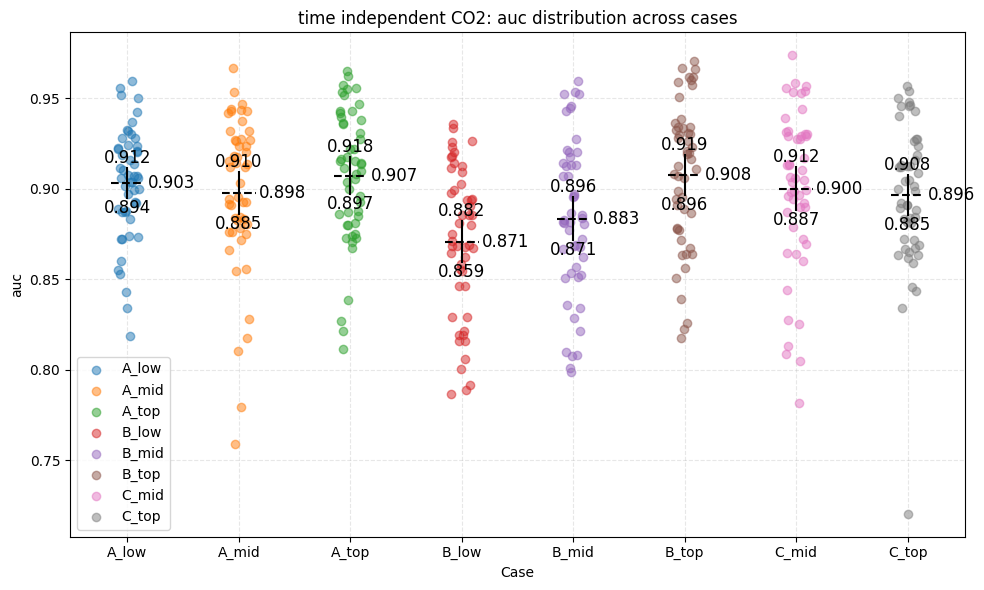

In [20]:
# plot auc
metric = "auc"

plt.figure(figsize=(10, 6))
for case in case_order:
    subset = df_metrics[df_metrics['case'] == case]
    plt.scatter(subset['x_jitter'], subset[metric], alpha=0.5, label=case)

for i, case in enumerate(case_order):
    vals = df_metrics[df_metrics['case'] == case][metric].values
    n = len(vals)
    mean_val = np.mean(vals)
    sem = stats.sem(vals)                  # standard error
    ci_low, ci_high = stats.t.interval(
        0.95, n - 1, loc=mean_val, scale=sem
    )
    plt.hlines(mean_val, i - 0.15, i + 0.15, colors='black', linestyles='dashed')
    plt.text(i + 0.18, mean_val, f"{mean_val:.3f}", va="center", ha="left", fontsize=12, color="black")
    plt.vlines(i, ci_low, ci_high, colors='black', linewidth=1.5)
    plt.text(i, ci_low, f"{ci_low:.3f}", va="top", ha="center", fontsize=12, color="black")
    plt.text(i, ci_high, f"{ci_high:.3f}", va="bottom", ha="center", fontsize=12, color="black")

plt.xticks(range(len(case_order)), case_order)
plt.xlabel("Case")
plt.ylabel(metric)
plt.title(f"{model}: {metric} distribution across cases")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

In [21]:
print(model)
check_anova_assumptions(
    df=df_metrics,
    group_col='case',
    metric_col='accuracy',
    group_order=case_order
)

time independent CO2

=== Normality test (D’Agostino and Pearson) for accuracy ===
A_low                    :	p = 0.8672	→	OK normal
A_mid                    :	p = 0.3065	→	OK normal
A_top                    :	p = 0.4455	→	OK normal
B_low                    :	p = 0.2992	→	OK normal
B_mid                    :	p = 0.3964	→	OK normal
B_top                    :	p = 0.7827	→	OK normal
C_mid                    :	p = 0.2625	→	OK normal
C_top                    :	p = 0.1597	→	OK normal

=== Normality test (Shapiro-Wilk) for accuracy ===
A_low                    :	p = 0.8218	→	OK normal
A_mid                    :	p = 0.5971	→	OK normal
A_top                    :	p = 0.5730	→	OK normal
B_low                    :	p = 0.2474	→	OK normal
B_mid                    :	p = 0.5026	→	OK normal
B_top                    :	p = 0.8465	→	OK normal
C_mid                    :	p = 0.2357	→	OK normal
C_top                    :	p = 0.1606	→	OK normal

=== Normality test (Anderson-Darling) for accuracy ===
A_low    

In [22]:
print(model)
check_anova_assumptions(
    df=df_metrics,
    group_col='case',
    metric_col='f1_weighted',
    group_order=case_order
)

time independent CO2

=== Normality test (D’Agostino and Pearson) for f1_weighted ===
A_low                    :	p = 0.8296	→	OK normal
A_mid                    :	p = 0.4183	→	OK normal
A_top                    :	p = 0.4204	→	OK normal
B_low                    :	p = 0.3745	→	OK normal
B_mid                    :	p = 0.4699	→	OK normal
B_top                    :	p = 0.7412	→	OK normal
C_mid                    :	p = 0.3071	→	OK normal
C_top                    :	p = 0.2496	→	OK normal

=== Normality test (Shapiro-Wilk) for f1_weighted ===
A_low                    :	p = 0.9220	→	OK normal
A_mid                    :	p = 0.5185	→	OK normal
A_top                    :	p = 0.4712	→	OK normal
B_low                    :	p = 0.3079	→	OK normal
B_mid                    :	p = 0.5584	→	OK normal
B_top                    :	p = 0.8230	→	OK normal
C_mid                    :	p = 0.2278	→	OK normal
C_top                    :	p = 0.2933	→	OK normal

=== Normality test (Anderson-Darling) for f1_weighted ===


In [23]:
print(model)
check_anova_assumptions(
    df=df_metrics,
    group_col='case',
    metric_col='balanced_acc',
    group_order=case_order
)

time independent CO2

=== Normality test (D’Agostino and Pearson) for balanced_acc ===
A_low                    :	p = 0.5039	→	OK normal
A_mid                    :	p = 0.2572	→	OK normal
A_top                    :	p = 0.2120	→	OK normal
B_low                    :	p = 0.4431	→	OK normal
B_mid                    :	p = 0.5363	→	OK normal
B_top                    :	p = 0.6333	→	OK normal
C_mid                    :	p = 0.9669	→	OK normal
C_top                    :	p = 0.3781	→	OK normal

=== Normality test (Shapiro-Wilk) for balanced_acc ===
A_low                    :	p = 0.8280	→	OK normal
A_mid                    :	p = 0.1662	→	OK normal
A_top                    :	p = 0.2880	→	OK normal
B_low                    :	p = 0.5645	→	OK normal
B_mid                    :	p = 0.2793	→	OK normal
B_top                    :	p = 0.6311	→	OK normal
C_mid                    :	p = 0.9876	→	OK normal
C_top                    :	p = 0.2403	→	OK normal

=== Normality test (Anderson-Darling) for balanced_acc =

In [24]:
print(model)
check_anova_assumptions(
    df=df_metrics,
    group_col='case',
    metric_col='auc',
    group_order=case_order
)

time independent CO2

=== Normality test (D’Agostino and Pearson) for auc ===
A_low                    :	p = 0.1692	→	OK normal
A_mid                    :	p = 0.0006	→	not normal
A_top                    :	p = 0.1778	→	OK normal
B_low                    :	p = 0.1359	→	OK normal
B_mid                    :	p = 0.4215	→	OK normal
B_top                    :	p = 0.2905	→	OK normal
C_mid                    :	p = 0.0521	→	OK normal
C_top                    :	p = 0.0000	→	not normal

=== Normality test (Shapiro-Wilk) for auc ===
A_low                    :	p = 0.2774	→	OK normal
A_mid                    :	p = 0.0011	→	not normal
A_top                    :	p = 0.0541	→	OK normal
B_low                    :	p = 0.0472	→	not normal
B_mid                    :	p = 0.2259	→	OK normal
B_top                    :	p = 0.0909	→	OK normal
C_mid                    :	p = 0.0144	→	not normal
C_top                    :	p = 0.0002	→	not normal

=== Normality test (Anderson-Darling) for auc ===
A_low             

### ANOVA

In [25]:
print(model)
run_anova_full(
    df=df_metrics,
    group_col='case',
    metric_col='accuracy'
)

time independent CO2

=== Welch ANOVA for accuracy ===
Source  ddof1      ddof2        F    p-unc     np2
  case      7 167.899855 4.103644 0.000347 0.07037

Effect size (partial η², np2) = 0.0704 → medium effect

=== Games-Howell post-hoc test for accuracy ===
    A     B  mean(A)  mean(B)      diff       se         T        df     pval    hedges
A_low A_mid 0.865197 0.868560 -0.003363 0.008785 -0.382791 94.870494 0.999939 -0.075971
A_low A_top 0.865197 0.870178 -0.004981 0.008730 -0.570589 95.204961 0.999137 -0.113242
A_low B_low 0.865197 0.837450  0.027747 0.008778  3.161096 94.913938 0.042262  0.627368
A_low B_mid 0.865197 0.850832  0.014365 0.009362  1.534296 90.897820 0.786877  0.304505
A_low B_top 0.865197 0.880964 -0.015767 0.008295 -1.900866 97.344284 0.553712 -0.377256
A_low C_mid 0.865197 0.872414 -0.007217 0.008440 -0.855001 96.753416 0.989204 -0.169688
A_low C_top 0.865197 0.863320  0.001878 0.008993  0.208793 93.508078 0.999999  0.041438
A_mid A_top 0.868560 0.870178 -0.0

In [26]:
print(model)
run_anova_full(
    df=df_metrics,
    group_col='case',
    metric_col='f1_weighted'
)

time independent CO2

=== Welch ANOVA for f1_weighted ===
Source  ddof1      ddof2       F    p-unc      np2
  case      7 167.890701 4.09226 0.000357 0.070327

Effect size (partial η², np2) = 0.0703 → medium effect

=== Games-Howell post-hoc test for f1_weighted ===
    A     B  mean(A)  mean(B)      diff       se         T        df     pval    hedges
A_low A_mid 0.862272 0.864417 -0.002144 0.009282 -0.231011 94.068037 0.999998 -0.045848
A_low A_top 0.862272 0.867944 -0.005672 0.009092 -0.623818 95.220236 0.998466 -0.123806
A_low B_low 0.862272 0.832902  0.029370 0.009268  3.168867 94.154775 0.041431  0.628911
A_low B_mid 0.862272 0.848026  0.014246 0.009689  1.470240 91.344621 0.821032  0.291792
A_low B_top 0.862272 0.879036 -0.016764 0.008586 -1.952498 97.519506 0.518949 -0.387503
A_low C_mid 0.862272 0.869732 -0.007459 0.008830 -0.844800 96.589687 0.989946 -0.167664
A_low C_top 0.862272 0.859658  0.002615 0.009413  0.277756 93.221360 0.999993  0.055125
A_mid A_top 0.864417 0.86794

In [27]:
print(model)
run_anova_full(
    df=df_metrics,
    group_col='case',
    metric_col='balanced_acc'
)

time independent CO2

=== Welch ANOVA for balanced_acc ===
Source  ddof1      ddof2         F        p-unc      np2
  case      7 167.815715 10.233985 1.190719e-10 0.147305

Effect size (partial η², np2) = 0.1473 → large effect

=== Games-Howell post-hoc test for balanced_acc ===
    A     B  mean(A)  mean(B)      diff       se         T        df         pval    hedges
A_low A_mid 0.827098 0.829750 -0.002652 0.008061 -0.328967 85.868394 9.999782e-01 -0.065289
A_low A_top 0.827098 0.840517 -0.013418 0.007509 -1.786873 90.836198 6.304461e-01 -0.354633
A_low B_low 0.827098 0.793528  0.033570 0.007046  4.764108 94.817119 1.791950e-04  0.945511
A_low B_mid 0.827098 0.816790  0.010308 0.007505  1.373439 90.872125 8.668520e-01  0.272580
A_low B_top 0.827098 0.852199 -0.025101 0.007003 -3.584199 95.148211 1.206265e-02 -0.711340
A_low C_mid 0.827098 0.840021 -0.012922 0.007177 -1.800442 93.756079 6.213640e-01 -0.357326
A_low C_top 0.827098 0.827797 -0.000698 0.007348 -0.095055 92.281972 1.0000

In [28]:
print(model)
run_anova_full(
    df=df_metrics,
    group_col='case',
    metric_col='auc'
)

time independent CO2

=== Welch ANOVA for auc ===
Source  ddof1     ddof2       F    p-unc      np2
  case      7 167.78318 4.81601 0.000058 0.081212

Effect size (partial η², np2) = 0.0812 → medium effect

=== Games-Howell post-hoc test for auc ===
    A     B  mean(A)  mean(B)      diff       se         T        df     pval    hedges
A_low A_mid 0.903180 0.897588  0.005592 0.007551  0.740559 88.778535 0.995456  0.146975
A_low A_top 0.903180 0.907215 -0.004035 0.006860 -0.588173 94.961328 0.998950 -0.116732
A_low B_low 0.903180 0.870615  0.032564 0.007338  4.437666 90.763405 0.000651  0.880723
A_low B_mid 0.903180 0.883345  0.019835 0.007550  2.627161 88.790564 0.160161  0.521401
A_low B_top 0.903180 0.907549 -0.004370 0.007193 -0.607451 92.097982 0.998703 -0.120558
A_low C_mid 0.903180 0.899914  0.003266 0.007643  0.427324 87.927841 0.999872  0.084809
A_low C_top 0.903180 0.896279  0.006901 0.007233  0.954048 91.734385 0.979539  0.189346
A_mid A_top 0.897588 0.907215 -0.009627 0.0080